In [2]:
import pandas as pd
import numpy as np

test_df = pd.read_csv("test.csv")
train_df = pd.read_csv("train.csv")

train_df.head()

,age,country,city,school,faculty,student_id,sociodemographics,test_score,application_id,personal_statement,accepted
0,24,Россия,Санкт-Петербург,9,0,7127004,1f63c614a798186e5b5dbca02201a070,21.0,06c4288fba116e49f49d82a16184fca6,NaN,0.0
1,21,Казахстан,Астана,5,0,6264436,99fec0c12216abee9eec3bee2138754f,29.0,45273a0d372f7f2747afc98bdc63c31a,NaN,1.0
2,17,Россия,Тула,3,0,9056805,f733e24fc7ae975aab7c3e092b1ae96c,89.0,773c820049150b6854691b5e7fdcd63f,NaN,0.0
3,20,Украина,Киев,1,0,8857612,a2b7795cd58502654754ce03163a1685,2.0,d07f757f1b51f8b9189a84298b142794,NaN,0.0
4,19,Россия,Пермь,8,0,6422527,90519fbbfd457329160e9c1767cb0a86,23.0,269f19b2ef9f46af5012931bfd4acf22,NaN,0.0


In [2]:
train_df.groupby("sociodemographics")["accepted"].sum()

sociodemographics
018b629d5bb1e0a83ccbbbf278e6a3bb    307.0
02c5b0703591918580defbd01237f650    598.0
035fc68d3b01212436f45052d220f797    426.0
05ec3873d1ced60fb3d4327bfd368e00    472.0
10e4180bd42c7cb8a9b203d61b32fd4c    507.0
                                    ...  
eef37152b2d557a1ecd7313a26003975    513.0
f1eef626c29a481a5527d242ae5516a8    318.0
f733e24fc7ae975aab7c3e092b1ae96c    360.0
fe8ad6510dffe532ea8fe0cf854f1427    323.0
ff43c402b75de2419d4bdf4b96ea6c40    480.0
Name: accepted, Length: 72, dtype: float64

In [3]:
test_df["student_id"].nunique(), test_df.shape

(19987, (24000, 11))

In [4]:
train_df["student_id"].nunique(), train_df.shape

(79767, (96000, 11))

In [5]:
id_counts = train_df['student_id'].value_counts().sort_values(ascending=False)

top_ids = id_counts.head(5).index
top_rep_df = train_df[train_df["student_id"].isin(top_ids)].sort_values(by='student_id')
top_rep_df

,age,country,city,school,faculty,student_id,sociodemographics,test_score,application_id,personal_statement,accepted
94238,24,Беларусь,Брест,2,5,1723310,639879d0115e8075d21a7619d63c41ee,49.0,8f588fe52e9bd2bffe0a10016103fa95,NaN,1.0
69335,19,Украина,Одесса,7,4,1723310,25475d9d46d73155c3e20850c38fc32a,74.0,9f56a4d08c59aefcaf549eb2573881c7,NaN,0.0
66439,24,Беларусь,Брест,2,4,1723310,639879d0115e8075d21a7619d63c41ee,49.0,8f588fe52e9bd2bffe0a10016103fa95,NaN,0.0
31030,19,Украина,Одесса,7,1,1723310,25475d9d46d73155c3e20850c38fc32a,74.0,9f56a4d08c59aefcaf549eb2573881c7,NaN,1.0
78762,21,Россия,Курск,7,4,2580429,adcb62fdc1121af780dc4138486cc7e3,66.0,40bb17d15b4c6b65daed25941cc450de,NaN,0.0
91279,21,Россия,Курск,7,5,2580429,adcb62fdc1121af780dc4138486cc7e3,66.0,40bb17d15b4c6b65daed25941cc450de,NaN,1.0
13289,24,Казахстан,Астана,5,0,2580429,4843860eb8d7bef21a5894797af4970a,7.0,7018da3afc2c2fc1f5b9b874ae973893,NaN,0.0
36672,24,Казахстан,Астана,5,2,2580429,4843860eb8d7bef21a5894797af4970a,7.0,7018da3afc2c2fc1f5b9b874ae973893,NaN,1.0
60603,23,Украина,Кривой Рог,14,3,3810351,dadaef222d17af71e34a4d39f182d7ae,57.0,dfefa7fbf08045bfe24cf4a561a066b6,NaN,0.0
61703,18,Беларусь,Витебск,4,3,3810351,b0f371fa4e704cac2af1c0bbdfa11940,37.0,bfd3e57ce7e02fdfdcdfc8b6244b7f70,NaN,1.0


In [41]:
train_df["application_id"].nunique(), train_df.shape

(79885, (96000, 11))

In [7]:
app_rep_id = train_df["application_id"].value_counts().head(4).index
app_rep_df = train_df[train_df["application_id"].isin(app_rep_id)].sort_values(by="application_id")
app_rep_df

,age,country,city,school,faculty,student_id,sociodemographics,test_score,application_id,personal_statement,accepted
13404,19,Украина,Кривой Рог,2,0,2150432,185ff2a5e1230ddb0434975524432a6c,60.0,0ac84af666cafe8a2fbafc37e25eec8a,NaN,1.0
25708,21,Казахстан,Караганда,6,1,2150432,99fec0c12216abee9eec3bee2138754f,9.0,0ac84af666cafe8a2fbafc37e25eec8a,NaN,0.0
39164,19,Украина,Кривой Рог,2,2,2150432,185ff2a5e1230ddb0434975524432a6c,60.0,0ac84af666cafe8a2fbafc37e25eec8a,NaN,0.0
13489,24,Казахстан,Актау,15,0,1627759,4843860eb8d7bef21a5894797af4970a,43.0,6cb5bd6556fe31110062d4086e898487,NaN,1.0
74988,24,Казахстан,Актау,15,4,1627759,4843860eb8d7bef21a5894797af4970a,43.0,6cb5bd6556fe31110062d4086e898487,NaN,0.0
83054,20,Казахстан,Павлодар,3,5,1627759,4770b72d5089a17da7bd0c67a41d4e32,8.0,6cb5bd6556fe31110062d4086e898487,NaN,0.0
22797,20,Украина,Киев,10,1,8534232,a2b7795cd58502654754ce03163a1685,100.0,8c1ff56a1d82d34df22850a96f6f9f04,NaN,0.0
63370,18,Россия,Рязань,16,3,8534232,9f2e1b173d3fc6d305927e37ee74ac91,39.0,8c1ff56a1d82d34df22850a96f6f9f04,NaN,1.0
75299,18,Россия,Рязань,16,4,8534232,9f2e1b173d3fc6d305927e37ee74ac91,39.0,8c1ff56a1d82d34df22850a96f6f9f04,NaN,0.0
78362,20,Украина,Киев,10,4,8534232,a2b7795cd58502654754ce03163a1685,100.0,8c1ff56a1d82d34df22850a96f6f9f04,NaN,1.0


In [14]:
test_df["application_id"].isin(train_df["application_id"].unique()).sum()

105

In [16]:
test_df["student_id"].isin(train_df["student_id"].unique()).sum(), test_df.shape

(229, (24000, 11))

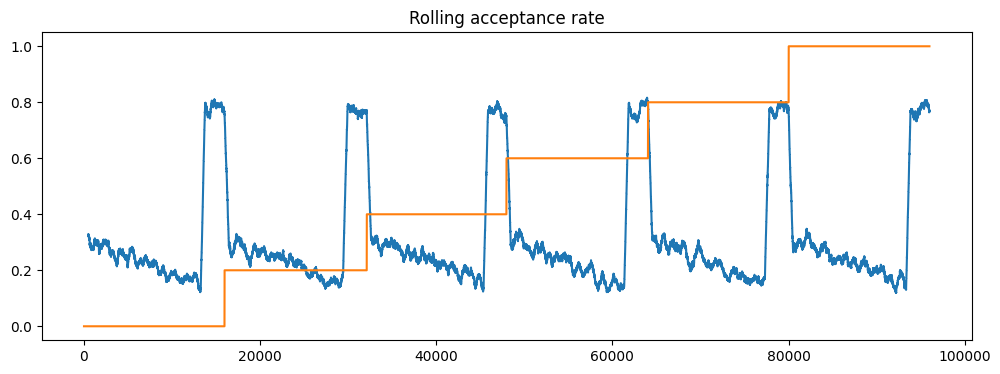

In [7]:
import matplotlib.pyplot as plt

train_df["accepted"].rolling(500).mean().plot(figsize=(12,4))
plt.title("Rolling acceptance rate")
(train_df["faculty"] / 5).plot()
plt.show()

In [13]:
test_df[test_df["test_score"] % 1 != 0]

,ID,age,country,city,school,faculty,student_id,sociodemographics,test_score,application_id,personal_statement
24,96024,25,Украина,Одесса,18,0,7410470,664452c22006a9ed7cdf2f74f68f078d,3.02,50c8f7f5108f8baa38112f7ede4c42d6,NaN
29,96029,21,Беларусь,Гомель,16,0,8203942,caf77419cb9dcedac5b8f36b58e3c572,18.22,89d5898789b9fa417ae962626d5a13c8,NaN
69,96069,24,Украина,Харьков,16,0,2043744,c35fb088b2e889aeb1f99fc9d21292a5,46.47,75badf19381481cb9286e9642572f4b5,NaN
95,96095,17,Россия,Улан-Удэ,3,0,8056945,a2e56b1228f7a0ed258b802f5d7c783d,70.89,c12c0aed90a38666c9c2352960fb4755,NaN
100,96100,19,Украина,Одесса,3,0,2837484,25475d9d46d73155c3e20850c38fc32a,89.54,f15bbba77714f9b7b9666686613505c5,NaN
...,...,...,...,...,...,...,...,...,...,...,...
23832,119832,24,Россия,Ульяновск,7,5,4093034,67086df93882a3958b6163a60d0bd6b5,23.19,a2567114ae511583e9179c63af749132,NaN
23920,119920,25,Казахстан,Караганда,16,5,8372404,10e4180bd42c7cb8a9b203d61b32fd4c,41.83,3283516bb248e339d2dd7cf24ff60414,NaN
23927,119927,23,Казахстан,Алматы,11,5,3369364,54f0cdd4b591cd3f93576f9b441d1341,11.92,f1df800d2bba94229ad4eaf84ef0480e,NaN
23931,119931,19,Беларусь,Могилёв,3,5,5951407,ff43c402b75de2419d4bdf4b96ea6c40,88.51,7dc841fff814116d27729dca3987614d,NaN


In [15]:
train_has_float = (train_df["test_score"] % 1 != 0).mean()
test_has_float  = (test_df["test_score"] % 1 != 0).mean()

print(train_has_float, test_has_float)

0.034604166666666665 0.03191666666666667
